In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df.shape

(200, 5)

In [3]:
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


In [5]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
df.describe().style.background_gradient()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


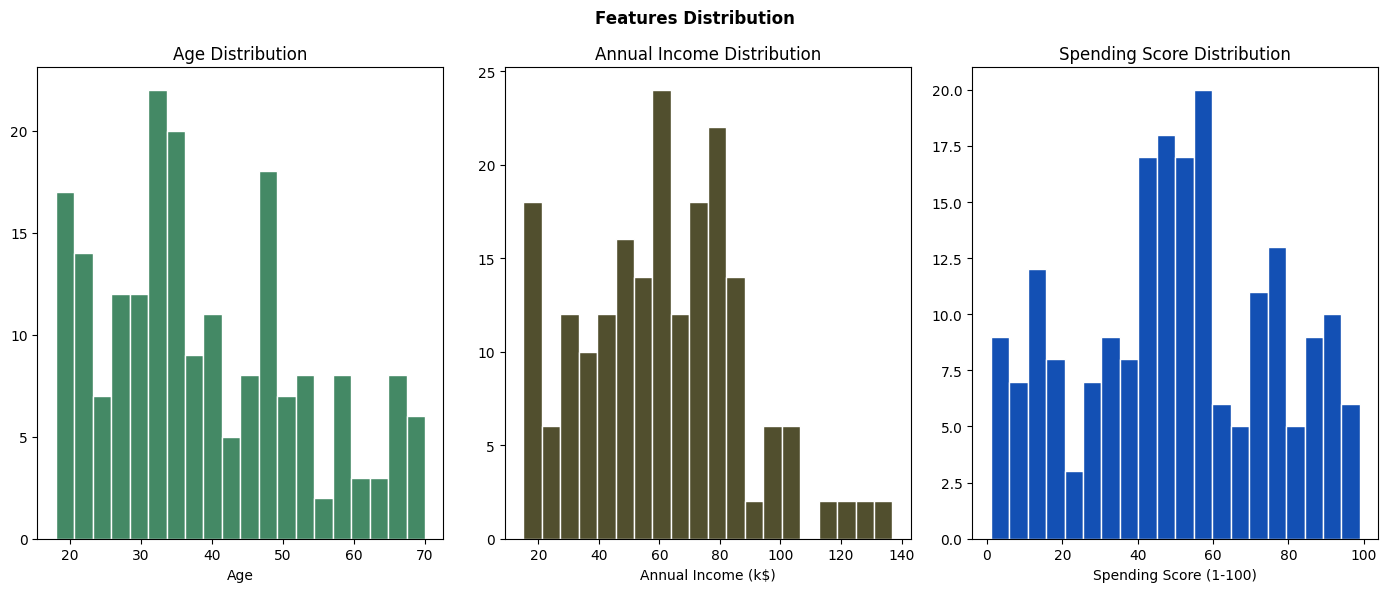

In [7]:
fig, axes = plt.subplots(1,3,figsize = (14,6))
fig.suptitle("Features Distribution", fontweight = 'bold')

axes[0].hist(df['Age'],color = '#448965',edgecolor = 'white',bins = 20)
axes[0].set_title("Age Distribution")
axes[0].set_xlabel('Age')

axes[1].hist(df['Annual Income (k$)'],color = "#514F2E",edgecolor = 'white',bins = 20)
axes[1].set_title("Annual Income Distribution")
axes[1].set_xlabel("Annual Income (k$)")

axes[2].hist(df['Spending Score (1-100)'],color = "#1350B4",edgecolor = 'white',bins = 20)
axes[2].set_title("Spending Score Distribution")
axes[2].set_xlabel("Spending Score (1-100)")

plt.tight_layout()
plt.show()

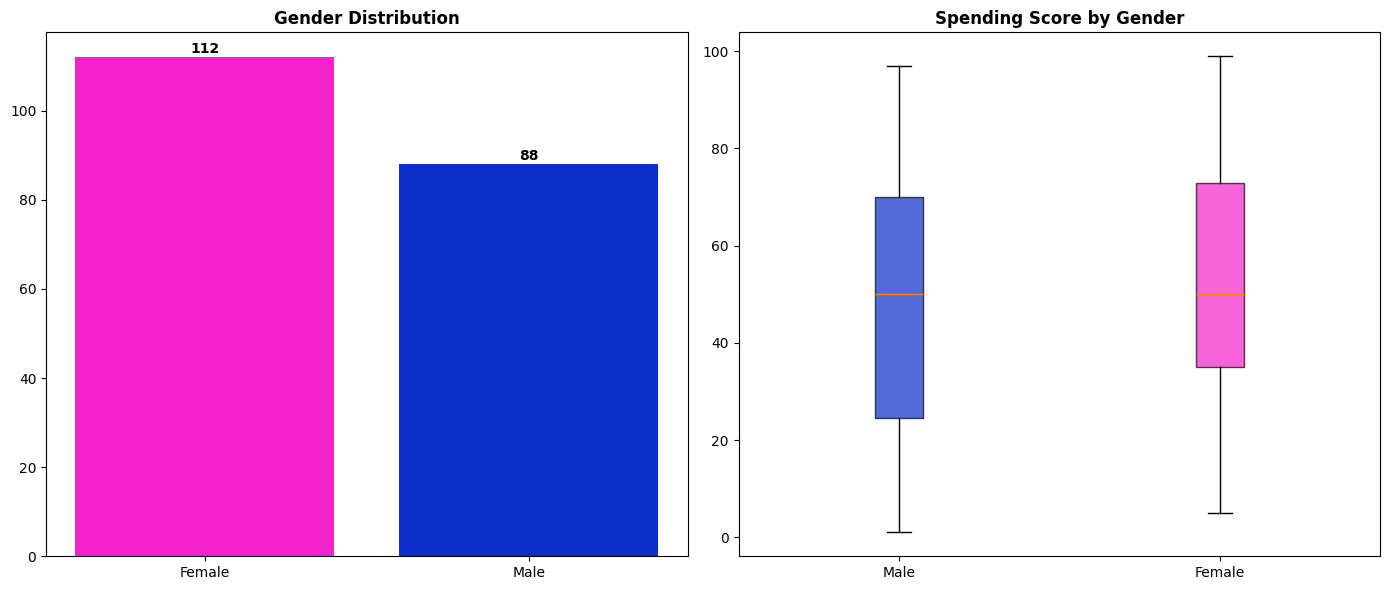

In [8]:
fig, axes = plt.subplots(1,2,figsize = (14,6))

gc = df['Gender'].value_counts()
axes[0].bar(gc.index,gc.values,color = ["#f422ca","#0B2ECA"])
axes[0].set_title('Gender Distribution', fontweight='bold')
for i, v in enumerate(gc.values): axes[0].text(i, v+1, str(v), ha='center', fontweight='bold')

color = ["#0B2ECA","#f422ca"]
bp = axes[1].boxplot(
    [df[df['Gender']=='Male']['Spending Score (1-100)'],
     df[df['Gender']=='Female']['Spending Score (1-100)']],
    labels=['Male','Female'], patch_artist=True)
for patch, color in zip(bp['boxes'], color):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_title('Spending Score by Gender', fontweight='bold')

plt.tight_layout()
plt.show()

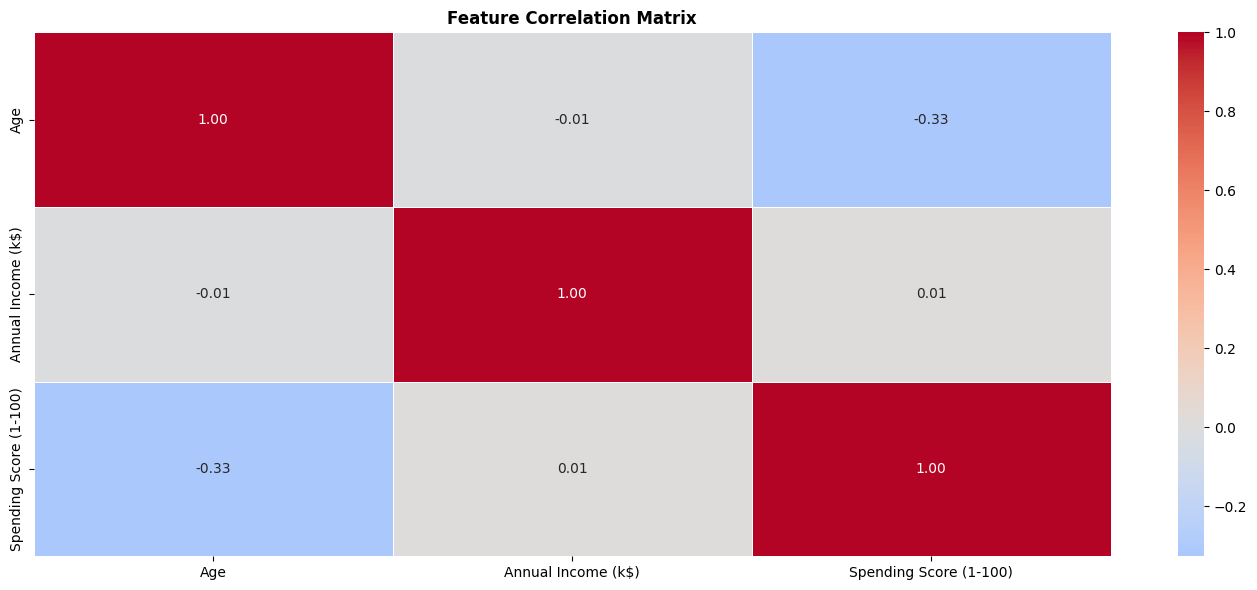

In [9]:
fig, ax = plt.subplots(figsize=(14,6))
corr = df[['Age','Annual Income (k$)','Spending Score (1-100)']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

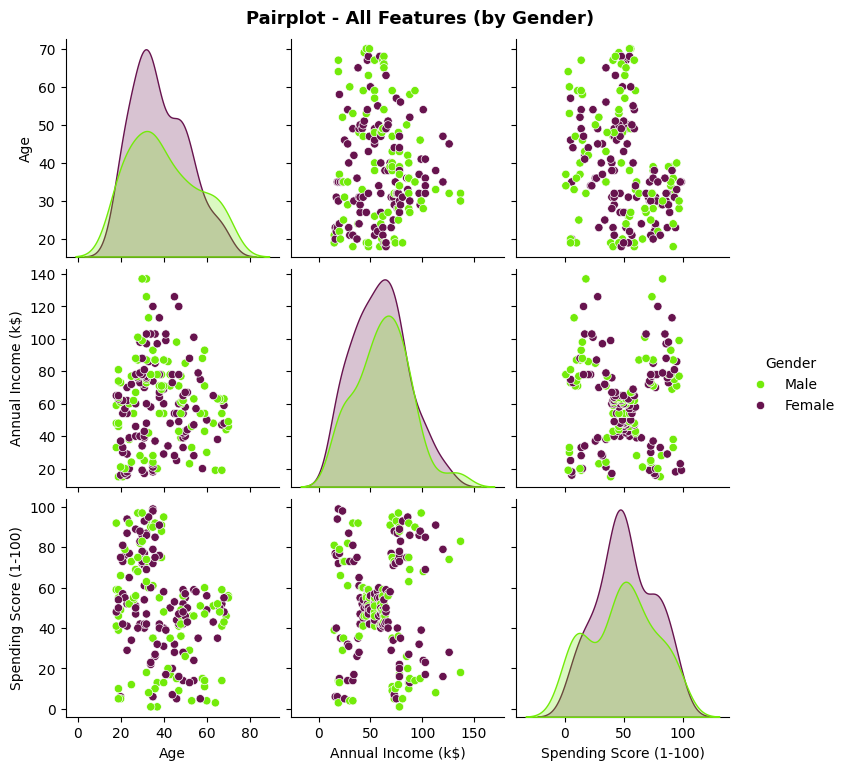

In [10]:
sns.pairplot(df.drop('CustomerID', axis=1),hue= 'Gender',palette= {'Male':"#73EB0A", 'Female':"#67134E"})

plt.suptitle('Pairplot - All Features (by Gender)', y=1.02, fontsize=13, fontweight='bold')
plt.show()

In [11]:
X2 = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

scaler = StandardScaler()
X3 = scaler.fit_transform(df[['Age','Annual Income (k$)','Spending Score (1-100)']].values)

print('2D feature matrix shape:', X2.shape)
print('3D scaled matrix shape :', X3.shape)

2D feature matrix shape: (200, 2)
3D scaled matrix shape : (200, 3)


In [12]:
wcss, sil_scores = [], []
K_range = range(2,11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X2)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X2, km.labels_))

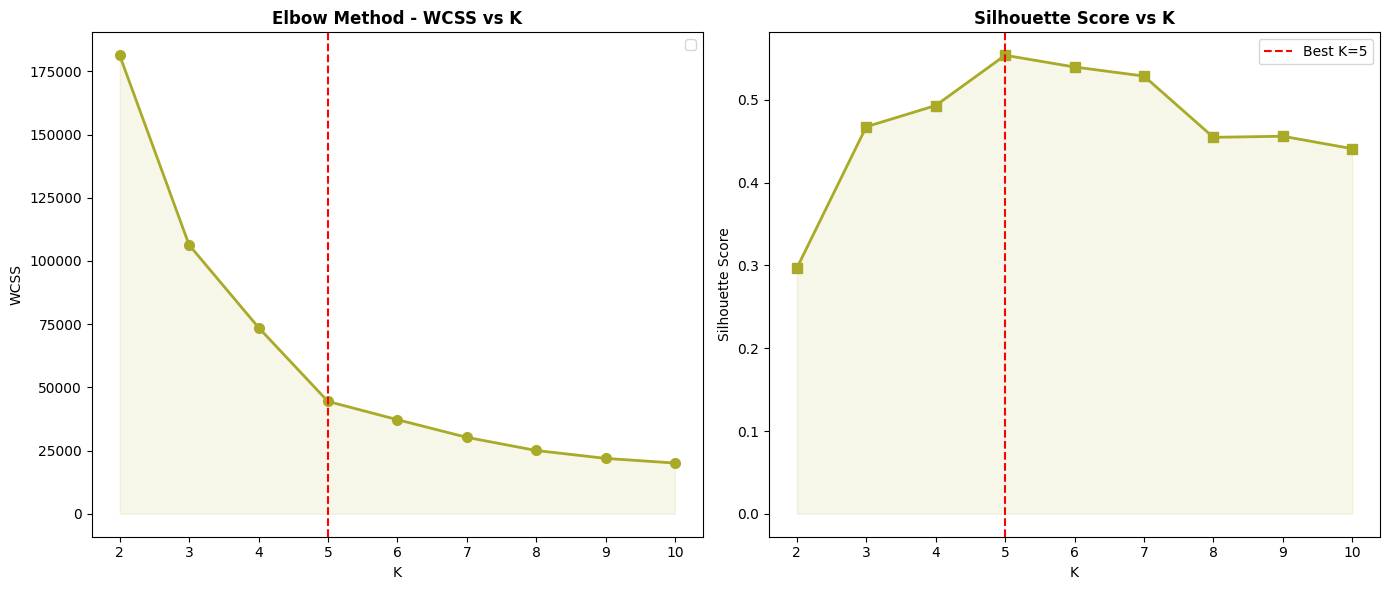

Best K by Silhouette: 5  (Score: 0.5539)


In [13]:
fig, axes = plt.subplots(1,2, figsize = (14,6))

axes[0].plot(K_range, wcss, 'o-', color='#AAAA29', linewidth=2, markersize=7)
axes[0].fill_between(K_range, wcss, color='#AAAA29',alpha = 0.1)
axes[0].set_title('Elbow Method - WCSS vs K', fontweight='bold')
axes[0].set_xlabel('K')
axes[0].set_ylabel('WCSS')
axes[0].legend()
axes[0].axvline(x=5, color='red', linestyle='--', linewidth=1.5, label='Optimal K=5')
axes[0].set_xticks(list(K_range))

best_k = list(K_range)[sil_scores.index(max(sil_scores))]
axes[1].plot(K_range, sil_scores,'s-', color='#AAAA29',linewidth=2, markersize=7)
axes[1].fill_between(K_range, sil_scores, color='#AAAA29',alpha = 0.1)
axes[1].axvline(x=best_k, color='red', linestyle='--', linewidth=1.5, label=f'Best K={best_k}')
axes[1].set_title('Silhouette Score vs K', fontweight='bold')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].set_xticks(list(K_range))

plt.tight_layout()
plt.show()
print(f'Best K by Silhouette: {best_k}  (Score: {max(sil_scores):.4f})')

In [14]:
K_BEST = 5
km5 = KMeans(n_clusters=K_BEST, init='k-means++', n_init=10, random_state=42)
labels5 = km5.fit_predict(X2)

In [15]:
kmeans = KMeans(n_clusters=5, init='k-means++',n_init=10,random_state=42)
df['Cluster'] = kmeans.fit_predict(X2)
centroids = kmeans.cluster_centers_

In [16]:
print('Cluster Centroids (Income k$, Spending Score):')
for i, c in enumerate(centroids):
    print(f'  Cluster {i+1}: Income = {c[0]:.1f}k$   Spending Score = {c[1]:.1f}')

Cluster Centroids (Income k$, Spending Score):
  Cluster 1: Income = 55.3k$   Spending Score = 49.5
  Cluster 2: Income = 86.5k$   Spending Score = 82.1
  Cluster 3: Income = 25.7k$   Spending Score = 79.4
  Cluster 4: Income = 88.2k$   Spending Score = 17.1
  Cluster 5: Income = 26.3k$   Spending Score = 20.9


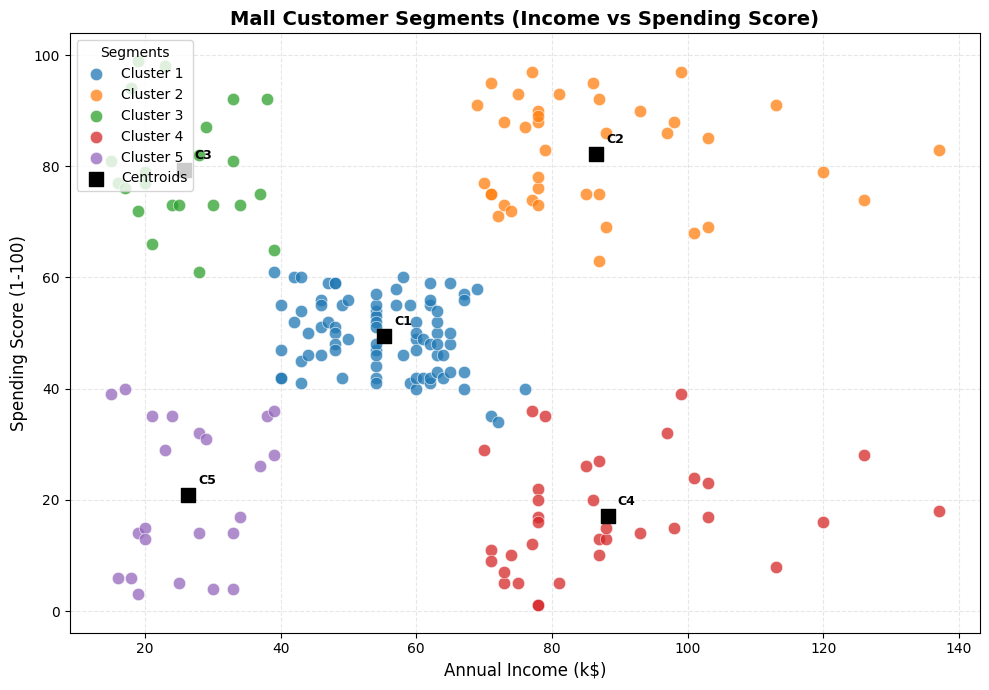

In [17]:
fig, ax = plt.subplots(figsize =(10,7))

for i in range(5):
    mask = df['Cluster'] == i
    ax.scatter(df.loc[mask, 'Annual Income (k$)'],df.loc[mask, 'Spending Score (1-100)'],label=f'Cluster {i+1}',linewidths=0.5,edgecolors='w',zorder=3,s=80,alpha=0.75)

ax.scatter(centroids[:,0],centroids[:,1],color = 'k', label = 'Centroids', marker='s',s=100,zorder =5)

for i,c in enumerate(centroids):
    ax.annotate(f'C{i+1}',xy=c, xytext=(c[0]+1.5,c[1]+2),fontsize=9,fontweight='bold')
ax.set_title('Mall Customer Segments (Income vs Spending Score)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Annual Income (k$)', fontsize=12)
ax.set_ylabel('Spending Score (1-100)', fontsize=12)
ax.legend(title='Segments', loc='upper left')
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout(); plt.show()

In [18]:
wcss3 = []
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X3)
    wcss3.append(km.inertia_)

wcss3

[389.3861889564372,
 295.2122461555488,
 205.22514747675916,
 168.24758017556834,
 133.86842085478852,
 117.01155455889811,
 103.87329152383714,
 93.09289110041726,
 82.38515364526599]

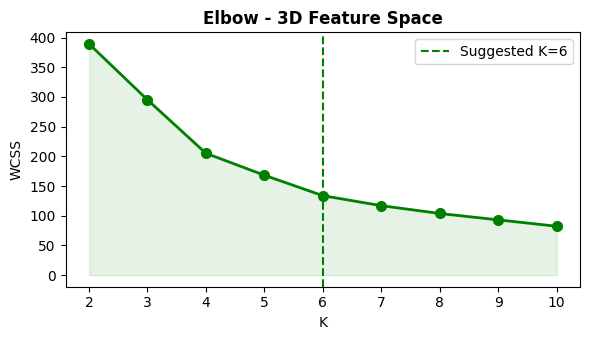

In [19]:
plt.figure(figsize=(6,3.5))
plt.plot(K_range, wcss3, 'o-', color='green', linewidth=2, markersize=7)
plt.fill_between(K_range, wcss3, alpha=0.1, color='green')
plt.axvline(x=6, color='green', linestyle='--', linewidth=1.5, label='Suggested K=6')
plt.title('Elbow - 3D Feature Space', fontweight='bold')
plt.xlabel('K'); plt.ylabel('WCSS'); plt.xticks(list(K_range)); plt.legend()
plt.tight_layout(); plt.show()

In [20]:
km3d = KMeans(n_clusters=6, init='k-means++', n_init=10, random_state=42)
labels_3d = km3d.fit_predict(X3)

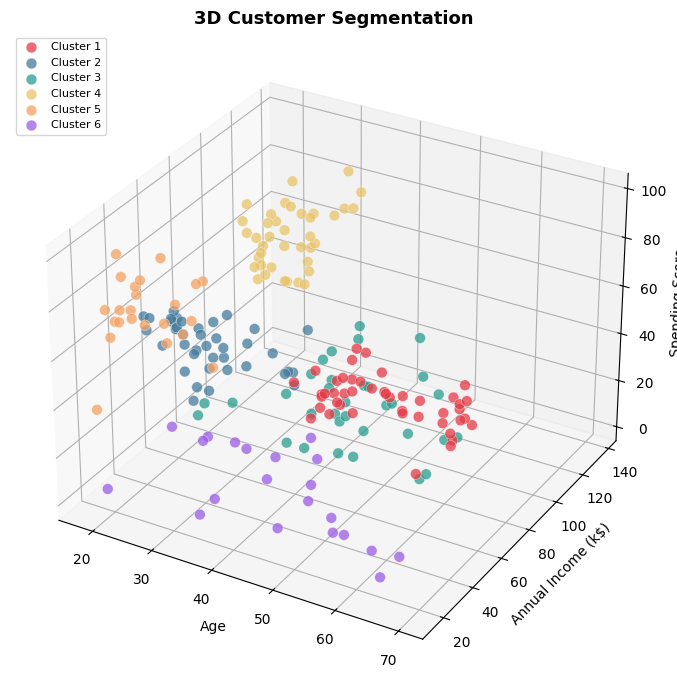

In [21]:
colors6 = ['#E63946','#457B9D','#2A9D8F','#E9C46A','#F4A261','#9B5DE5']
fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection='3d')

for i in range(6):
    mask = labels_3d == i
    ax.scatter(df.loc[mask,'Age'],
               df.loc[mask,'Annual Income (k$)'],
               df.loc[mask,'Spending Score (1-100)'],
               c=colors6[i], s=60, alpha=0.75,
               edgecolors='white', linewidths=0.3, label=f'Cluster {i+1}')

ax.set_xlabel('Age'); ax.set_ylabel('Annual Income (k$)'); ax.set_zlabel('Spending Score')
ax.set_title('3D Customer Segmentation', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

In [22]:
profile = df.groupby('Cluster').agg(
    Count        = ('CustomerID','count'),
    Avg_Age      = ('Age','mean'),
    Avg_Income   = ('Annual Income (k$)','mean'),
    Avg_Spending = ('Spending Score (1-100)','mean'),
    Female_Pct   = ('Gender', lambda x: round(100*(x=='Female').sum()/len(x),1))
).reset_index()
profile['Cluster'] = profile['Cluster'] + 1
profile.style.background_gradient(
    subset=['Avg_Income','Avg_Spending'], cmap='YlOrRd'
).format({'Avg_Age':'{:.1f}','Avg_Income':'{:.1f}','Avg_Spending':'{:.1f}','Female_Pct':'{:.1f}%'
}).hide(axis='index')

Cluster,Count,Avg_Age,Avg_Income,Avg_Spending,Female_Pct
1,81,42.7,55.3,49.5,59.3%
2,39,32.7,86.5,82.1,53.8%
3,22,25.3,25.7,79.4,59.1%
4,35,41.1,88.2,17.1,45.7%
5,23,45.2,26.3,20.9,60.9%


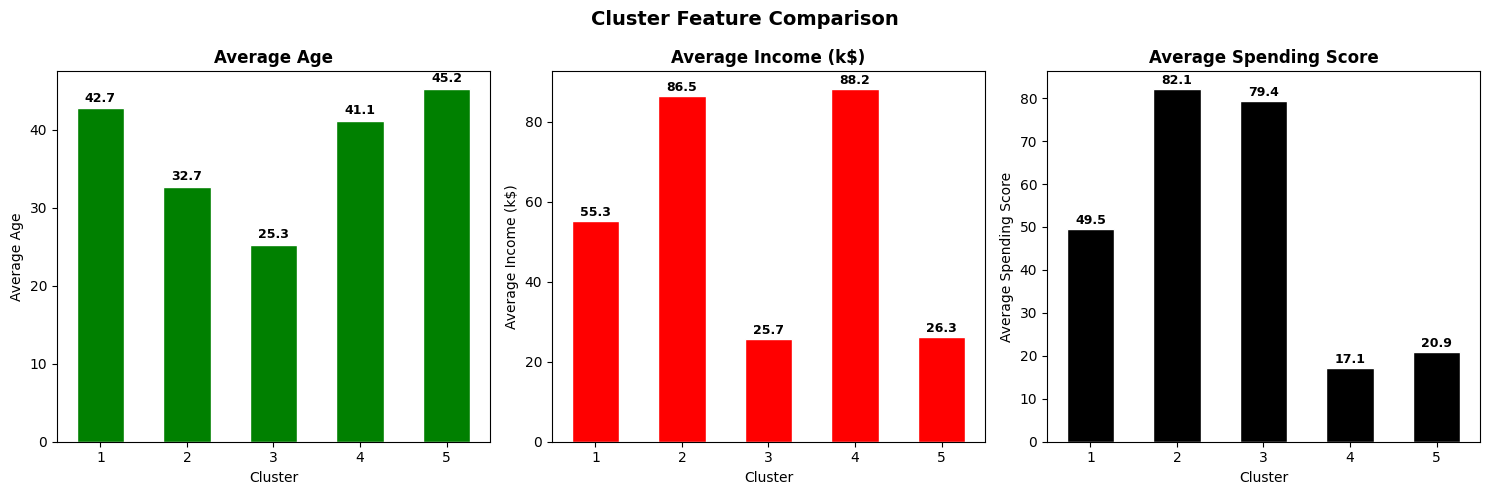

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Cluster Feature Comparison', fontsize=14, fontweight='bold')

metrics = ['Avg_Age','Avg_Income','Avg_Spending']
titles  = ['Average Age','Average Income (k$)','Average Spending Score']

for ax, col, title, color in zip(axes, metrics, titles, ['green','red','k']):
    bars = ax.bar(profile['Cluster'].astype(str), profile[col],
                  color=color, edgecolor='white', width=0.55)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Cluster'); ax.set_ylabel(title)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.5,
                f'{h:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout(); plt.show()

In [24]:
sil = silhouette_score(X2, df['Cluster'])
db  = davies_bouldin_score(X2, df['Cluster'])
ch  = calinski_harabasz_score(X2, df['Cluster'])

In [25]:
print(f'  Silhouette Score       : {sil:.4f}  (higher better, max 1)')
print(f'  Davies-Bouldin Index   : {db:.4f}  (lower better, min 0)')
print(f'  Calinski-Harabasz Index: {ch:.2f}  (higher better)')

  Silhouette Score       : 0.5539  (higher better, max 1)
  Davies-Bouldin Index   : 0.5726  (lower better, min 0)
  Calinski-Harabasz Index: 247.36  (higher better)


In [26]:
print('Cluster Size Distribution:')
sizes = df['Cluster'].value_counts().sort_index()
for c, s in sizes.items():
    print(f'  Cluster {c+1}: {s} customers ({100*s/len(df):.1f}%)')

Cluster Size Distribution:
  Cluster 1: 81 customers (40.5%)
  Cluster 2: 39 customers (19.5%)
  Cluster 3: 22 customers (11.0%)
  Cluster 4: 35 customers (17.5%)
  Cluster 5: 23 customers (11.5%)
